# <center>Introduction to panel data: pooled and fixed effects</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: econometrics</center>
#### <center>With python code examples</center>

© 2018–2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* Set up the panel data model with unobserved heterogeneity $\alpha_i$ and idiosyncratic error $\varepsilon_{it}$; state the strict-exogeneity condition for the idiosyncratic error and distinguish it from the additional orthogonality assumption imposed by random-effects models.

* Implement four estimators from scratch and confirm their algebraic relationships: pooled OLS, within (fixed effects), least-squares-dummy-variables (LSDV), and first differences.

* Extend the model with time fixed effects $\lambda_t$ absorbing period-common shocks: the springboard to difference-in-differences.

* Understand why observations within an individual are dependent, and compare classical, HC, and entity-clustered standard errors on the FE regression.

* Reproduce all of the above with the `linearmodels.panel` library on the Vella–Verbeek (1998) wage panel.

The random-effects estimator and the Hausman test against fixed effects are developed in **Lecture 5, §6**, where they arise as generalized least squares on the error-components covariance; this lecture takes the fixed-effects side of that comparison and develops it on its own terms.

### References

**[H]** Hansen, B. E. (2022). *Econometrics*. Princeton University Press. Chapter 17.

**[Wo]** Wooldridge, J. M. (2010). *Econometric Analysis of Cross Section and Panel Data*, 2nd ed. MIT Press. Chapters 10–11.

**[VV]** Vella, F., and Verbeek, M. (1998). 'Whose Wages Do Unions Raise? A Dynamic Model of Unionism and Wage Rate Determination for Young Men'. *Journal of Applied Econometrics*, 13(2), 163–183.

# Motivation: leveraging the within-individual dimension

* Cross-sectional regressions of log-wage on education, marriage, or union status are notoriously hard to interpret causally. Married men earn more than unmarried men, but it is unclear whether marriage *causes* higher wages or whether men with characteristics conducive to high wages are also more likely to marry. The omitted variable here is the latent quality of the worker, which is correlated with both wages and marriage status.

* Panel data, repeated observations of the same individuals over time, let us absorb such time-invariant unobserved heterogeneity through a person-specific intercept $\alpha_i$, and identify the parameter of interest from *within-person* variation alone. The cost is the loss of identification on time-invariant regressors and a (typically small) efficiency penalty if the heterogeneity is in fact uncorrelated with the regressors.

* This lecture works through the standard panel-data toolkit on the Vella–Verbeek (1998) wage panel, drawn from the Journal of Applied Econometrics archive: $I=545$ young American men observed over $T=8$ years (1980–1987), with information on hourly wage, marriage, union membership, and a handful of demographic controls.

> **Warning, what fixed effects do and do not do.** Fixed effects remove *time-invariant* unobserved heterogeneity. They do **not** remove time-varying confounding, reverse causality, anticipation, or feedback from past wage shocks to future marriage or union status. The strict-exogeneity condition of §1.1 is exactly the assumption that rules those channels out, an economic assumption, not a technicality.

## Loading our libraries

We use `linearmodels.panel` as the benchmark library (`pip install linearmodels`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from types import SimpleNamespace
import linearmodels.panel as lp

rng = np.random.default_rng(777)
plt.rcParams['figure.figsize'] = (8, 4.5)


## Loading our data: Vella–Verbeek (1998) wage panel

The data come with the Wooldridge textbook companion package `wooldridge` (`pip install wooldridge`); the underlying dataset is from Vella and Verbeek (1998, *JAE*) and is also distributed through the JAE archive at http://qed.econ.queensu.ca/jae/.

In [2]:
import wooldridge
wagepan = wooldridge.data('wagepan').copy()
print(f'Observations:  {len(wagepan)}')
print(f'Individuals:   {wagepan["nr"].nunique()}')
print(f'Years:         {sorted(wagepan["year"].unique())}')
print(f'Balanced?      {(wagepan.groupby("nr").size().nunique() == 1)}')
wagepan[['nr', 'year', 'lwage', 'educ', 'exper', 'married', 'union', 'black', 'hisp']].head(8)


Observations:  4360
Individuals:   545
Years:         [1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987]
Balanced?      True


,nr,year,lwage,educ,exper,married,union,black,hisp
0,13,1980,1.197540,14,1,0,0,0,0
1,13,1981,1.853060,14,2,0,1,0,0
2,13,1982,1.344462,14,3,0,0,0,0
3,13,1983,1.433213,14,4,0,0,0,0
4,13,1984,1.568125,14,5,0,0,0,0
5,13,1985,1.699891,14,6,0,0,0,0
6,13,1986,-0.720263,14,7,0,0,0,0
7,13,1987,1.669188,14,8,0,0,0,0


# 1. The panel data model

The basic panel regression is
$$
y_{it} = x_{it}^\top\beta + \alpha_i + \varepsilon_{it}, \qquad i\in[I],\;\; t\in[T],
$$
where $y_{it}\in\mathbb{R}$ is the outcome for unit $i$ at time $t$, $x_{it}\in\mathbb{R}^K$ is a vector of regressors, $\alpha_i$ is an unobserved time-invariant heterogeneity component, and $\varepsilon_{it}$ is the idiosyncratic error.

## 1.1 Strict exogeneity

We maintain throughout this lecture the *strict exogeneity* condition
$$
\mathbb{E}[\varepsilon_{it}\mid x_{i,1},\ldots,x_{i,T},\alpha_i] = 0, \qquad \forall i,t.
$$
This says that, after conditioning on the unobserved type $\alpha_i$, the idiosyncratic shock at time $t$ is mean-independent of the regressors at *all* dates, past, present, and future. It is *stronger* than contemporaneous exogeneity $\mathbb{E}[\varepsilon_{it}\mid x_{it}] = 0$ for the idiosyncratic error, by iterated expectations it implies it: because it additionally rules out feedback from shocks to *future* regressors. What fixed effects let us avoid is not this condition but the *composite* one, $\mathbb{E}[\alpha_i + \varepsilon_{it}\mid x_{it}] = 0$: FE permits $\alpha_i$ to be arbitrarily correlated with the regressors. Economically, strict exogeneity is exactly what the warning in the motivation requires: no feedback from this year's wage shock to next year's marriage or union status, and no anticipation of future shocks in today's choices.

## 1.2 Fixed vs random effects: a single distinction

The labels refer to one restriction on the relation between the unit effect $\alpha_i$ and the regressor history $x_{i\bullet}$:

> * **Fixed effects (FE):** $\alpha_i$ may be arbitrarily correlated with $x_{i\bullet}$; it is treated as a nuisance parameter to be eliminated.
> * **Random effects (RE):** that correlation is ruled out: $\mathbb{E}[\alpha_i\mid x_{i\bullet}] = \mathbb{E}[\alpha_i]$.
> * **This lecture uses FE.** RE estimation and the Hausman test were developed in Lecture 5, §6, where the RE estimator is GLS on the equicorrelated error-components covariance and the within estimator of this lecture is its $\theta\to1$ limit.

Strict exogeneity (a condition on $\varepsilon_{it}$) is maintained in both cases.

## 1.3 The Mincer specification on wagepan

We will work throughout with the regression
$$
\log(\text{wage}_{it}) = \beta_0 + \beta_{\text{exper}}\,\text{exper}_{it} + \beta_{\text{exper}^2}\,\text{exper}_{it}^2 + \beta_{\text{married}}\,\text{married}_{it} + \beta_{\text{union}}\,\text{union}_{it} + \alpha_i + \varepsilon_{it},
$$
adding the time-invariant demographic controls `educ`, `black`, `hisp` to the *pooled* specification (where they are identifiable) but dropping them from the *fixed-effects* specification (where they are not).

Set up the data once and re-use throughout.

In [3]:
# Multi-index for linearmodels and easy entity/time access
df = wagepan.set_index(['nr', 'year']).sort_index()

# Time-varying regressors used in every specification
xvars_tv = ['exper', 'expersq', 'married', 'union']
# Time-invariant regressors used only in pooled / RE
xvars_ti = ['educ', 'black', 'hisp']

I  = df.index.get_level_values('nr').nunique()
T  = df.index.get_level_values('year').nunique()
IT = len(df)
print(f'I = {I}, T = {T}, IT = {IT}')

y_it = df['lwage'].values
Xpool_it_k = np.column_stack([np.ones(IT)] + [df[v].values for v in xvars_tv + xvars_ti])
Xtv_it_k   = np.column_stack([df[v].values for v in xvars_tv])  # used in FE
names_pool = ['const'] + xvars_tv + xvars_ti
names_tv   = xvars_tv


I = 545, T = 8, IT = 4360


# 2. Pooled OLS

Stacking all $IT$ observations and ignoring the panel structure yields the pooled OLS estimator
$$
\hat\beta_{\text{POLS}} := \arg\min_b \sum_{i,t}(y_{it} - x_{it}^\top b)^2.
$$
Consistency for $\beta$ requires the population moment condition
$$
\mathbb{E}[x_{it}\,u_{it}] = 0, \qquad u_{it} := \alpha_i + \varepsilon_{it},
$$
together with the usual rank and sampling conditions (cf. Lecture 3). Conditional mean independence, $\mathbb{E}[u_{it}\mid x_{it}] = 0$, is sufficient for the moment condition but stronger. In fixed-effects settings the moment condition generally fails, because $\alpha_i$ is correlated with $x_{it}$. Even when pooled OLS is consistent, the composite error is equicorrelated within unit: under the error-components assumptions ($\varepsilon_{it}$ homoskedastic and serially uncorrelated across $t$, with $\alpha_i$ orthogonal to $\varepsilon_{it}$), $\operatorname{Corr}(u_{it},u_{is}) = \sigma_\alpha^2/(\sigma_\alpha^2+\sigma_\varepsilon^2)$ for $t\neq s$. This within-cluster correlation is *positive*, so classical or HC standard errors under-cover unless replaced by cluster-robust SEs at the entity level (cf. Lecture 4, §4).

In [4]:
def ols(X_it_k, y_it):
    XtXinv_k_k = np.linalg.inv(X_it_k.T @ X_it_k)
    β_k = XtXinv_k_k @ X_it_k.T @ y_it
    return SimpleNamespace(β_k=β_k, εhat_it=y_it - X_it_k @ β_k, XtXinv_k_k=XtXinv_k_k,
                           n_rows=len(y_it), K=X_it_k.shape[1])

fit_pool = ols(Xpool_it_k, y_it)
σ2 = (fit_pool.εhat_it @ fit_pool.εhat_it) / (IT - len(names_pool))
sepool_k = np.sqrt(np.diag(σ2 * fit_pool.XtXinv_k_k))
print(f"{'name':<10s}{'POLS β̂':>12s}{'classical s.e.':>17s}")
for name, b, s in zip(names_pool, fit_pool.β_k, sepool_k):
    print(f'{name:<10s}{b:>12.4f}{s:>17.4f}')


name           POLS β̂   classical s.e.
const          -0.0347           0.0646
exper           0.0892           0.0101
expersq        -0.0028           0.0007
married         0.1077           0.0157
union           0.1801           0.0171
educ            0.0994           0.0047
black          -0.1438           0.0236
hisp            0.0157           0.0208


## 2.1 Comparison with `linearmodels.PooledOLS`

In [5]:
mod_pool = lp.PooledOLS(df['lwage'],
                        df[xvars_tv + xvars_ti].assign(const=1.0)[['const'] + xvars_tv + xvars_ti])
res_pool = mod_pool.fit()
print(f'max |DIY β̂ - linearmodels β̂| = {np.max(np.abs(fit_pool.β_k - res_pool.params.values)):.2e}')


max |DIY β̂ - linearmodels β̂| = 2.38e-14


# 3. The within (fixed effects) estimator

## 3.1 The within transformation

For each unit $i$, define the time average $\bar y_i := T^{-1}\sum_t y_{it}$ (and analogously for the regressors). Subtracting from both sides of the panel equation eliminates $\alpha_i$:
$$
y_{it} - \bar y_i = (x_{it} - \bar x_i)^\top\beta + (\varepsilon_{it} - \bar\varepsilon_i).
$$
Running OLS on the demeaned variables $\tilde y_{it} := y_{it}-\bar y_i$ and $\tilde x_{it} := x_{it}-\bar x_i$ *defines* the within (fixed effects) estimator
$$
\hat\beta_{\text{FE}} := \Big(\sum_{i,t}\tilde x_{it}\tilde x_{it}^\top\Big)^{-1}\sum_{i,t}\tilde x_{it}\,\tilde y_{it}.
$$
Any time-invariant regressor is annihilated by the within transformation, its demeaned value is identically zero, so $\hat\beta_{\text{FE}}$ cannot identify the coefficient on `educ`, `black`, or `hisp`.

## 3.2 LSDV equivalence

An equivalent way to remove $\alpha_i$ is to include an intercept dummy for each unit and run OLS:
$$
y_{it} = x_{it}^\top\beta + \sum_{j\in[I]} \alpha_j\,\mathbf{1}\{i = j\} + \varepsilon_{it}.
$$
Let $\hat\beta_{\text{LSDV}}$ denote the OLS *slope* subvector of this regression: the estimated coefficients on $x_{it}$, the $\hat\alpha_j$ being the estimated unit intercepts. By the Frisch–Waugh–Lovell theorem (Lecture 3, §2), $\hat\beta_{\text{LSDV}} = \hat\beta_{\text{FE}}$: the within transformation is exactly partialling out the unit dummies. The $\hat\alpha_i$ recovered from LSDV are estimates of the individual fixed effects, which are not consistent as $T$ is fixed (incidental parameters), but cancel out of the slope coefficient.

## 3.3 Standard errors and degrees of freedom

The within residual is $\hat\varepsilon_{it} = (y_{it}-\bar y_i) - (x_{it}-\bar x_i)^\top\hat\beta_{\text{FE}}$. Since LSDV estimates $I$ intercepts plus $K_{\text{tv}}$ slopes ($K_{\text{tv}}$ being the number of time-varying regressors), the unbiased estimator of $\sigma_\varepsilon^2$ uses $IT - I - K_{\text{tv}}$ degrees of freedom:
$$
\hat\sigma_\varepsilon^2 = \frac{1}{IT - I - K_{\text{tv}}}\sum_{i,t}\hat\varepsilon_{it}^2.
$$
Beyond the degrees of freedom, the classical SEs rest on $\operatorname{Var}(\varepsilon_i\mid X_i,\alpha_i) = \sigma_\varepsilon^2 I_T$: independence of the shocks across periods *within* an individual. In practice shocks to the same person persist over time (health, employer, local conditions), so observations within an individual are dependent, classical SEs under-cover, and inference should be clustered at the entity level. Section 6 below compares classical, HC, and clustered SEs; the DIY sandwich construction is in the additional material.

## 3.4 DIY implementation

In [6]:
def within_demean(df, var_list, entity='nr'):
    out = df[var_list].copy()
    out -= df.groupby(level=entity)[var_list].transform('mean')
    return out.values

def ols_fe(df, y_var, x_vars, entity='nr'):
    Δy_it   = within_demean(df, [y_var], entity).ravel()
    ΔX_it_k = within_demean(df, x_vars, entity)
    n_rows, K = ΔX_it_k.shape
    I = df.index.get_level_values(entity).nunique()
    XtXinv_k_k = np.linalg.inv(ΔX_it_k.T @ ΔX_it_k)
    β_k = XtXinv_k_k @ ΔX_it_k.T @ Δy_it
    εhat_it = Δy_it - ΔX_it_k @ β_k
    σ2 = (εhat_it @ εhat_it) / (n_rows - I - K)      # *correct* dof: IT - I - K_tv
    V_k_k = σ2 * XtXinv_k_k
    return SimpleNamespace(β_k=β_k, εhat_it=εhat_it, σ2=σ2, V_k_k=V_k_k,
                           se_k=np.sqrt(np.diag(V_k_k)), n_rows=n_rows, I=I, K=K)

fit_fe = ols_fe(df, 'lwage', xvars_tv)
print(f"{'name':<10s}{'FE β̂':>12s}{'classical s.e.':>17s}")
for name, b, s in zip(names_tv, fit_fe.β_k, fit_fe.se_k):
    print(f'{name:<10s}{b:>12.4f}{s:>17.4f}')


name             FE β̂   classical s.e.
exper           0.1168           0.0084
expersq        -0.0043           0.0006
married         0.0453           0.0183
union           0.0821           0.0193


Let us see what the within transformation actually removes. The left panel plots raw log-wage profiles for eight men: most of the spread on the vertical axis is *between* them, a permanent gap that experience does not explain, and the pooled regression line has to run through that cloud. The right panel subtracts each man's own mean from both variables. The permanent gaps vanish by construction, and what is left is the only variation the fixed-effects estimator uses.

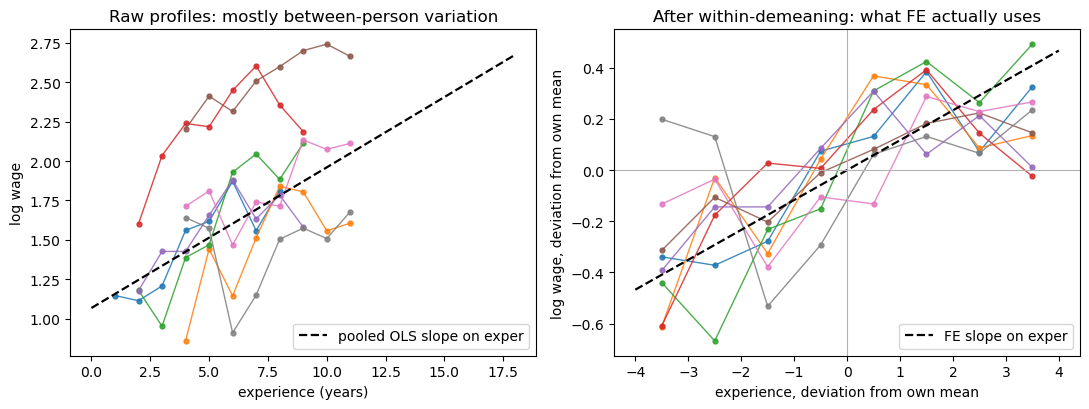

pooled OLS slope on exper = 0.0892
fixed-effects slope       = 0.1168


In [7]:
rng_pick = np.random.default_rng(777)
ids = df.index.get_level_values('nr').unique()
picked = rng_pick.choice(ids, size=8, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=False)
for nr in picked:
    block = df.loc[nr]
    axes[0].plot(block['exper'], block['lwage'], 'o-', ms=3.5, lw=1, alpha=0.85)
    axes[1].plot(block['exper'] - block['exper'].mean(),
                 block['lwage'] - block['lwage'].mean(),
                 'o-', ms=3.5, lw=1, alpha=0.85)

xs = np.linspace(df['exper'].min(), df['exper'].max(), 50)
b_pool = fit_pool.β_k[names_pool.index('exper')]
axes[0].plot(xs, df['lwage'].mean() + b_pool * (xs - df['exper'].mean()),
             color='k', ls='--', lw=1.6, label='pooled OLS slope on exper')
axes[0].set_xlabel('experience (years)')
axes[0].set_ylabel('log wage')
axes[0].set_title('Raw profiles: mostly between-person variation')
axes[0].legend(loc='lower right')

xd = np.linspace(-4, 4, 50)
b_fe = fit_fe.β_k[names_tv.index('exper')]
axes[1].plot(xd, b_fe * xd, color='k', ls='--', lw=1.6, label='FE slope on exper')
axes[1].axhline(0, color='0.7', lw=0.8)
axes[1].axvline(0, color='0.7', lw=0.8)
axes[1].set_xlabel('experience, deviation from own mean')
axes[1].set_ylabel('log wage, deviation from own mean')
axes[1].set_title('After within-demeaning: what FE actually uses')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'pooled OLS slope on exper = {b_pool:.4f}')
print(f'fixed-effects slope       = {b_fe:.4f}')


## 3.5 LSDV verification

We construct the $IT\times(I + K_{\text{tv}})$ matrix $[D\;\;X]$ where $D$ is a block-diagonal matrix of entity dummies (no intercept, to avoid the dummy-variable trap), run OLS, and verify that the slope coefficients on $X$ match the within estimator.

In [8]:
# Build entity dummies as a sparse matrix to keep memory manageable
import scipy.sparse as sp
entity_it = pd.factorize(df.index.get_level_values('nr'))[0]
D_it_i = sp.csr_matrix(
    (np.ones(IT), (np.arange(IT), entity_it)),
    shape=(IT, I),
)
Xlsdv_it_p = sp.hstack([D_it_i, sp.csr_matrix(Xtv_it_k)]).tocsr()

# Solve normal equations on the sparse system
θ_p = sp.linalg.spsolve(Xlsdv_it_p.T @ Xlsdv_it_p, Xlsdv_it_p.T @ y_it)
βlsdv_k = θ_p[I:]  # the last K_tv entries are the slopes on Xtv_it_k

print(f"{'name':<10s}{'FE (within)':>14s}{'LSDV':>12s}{'difference':>14s}")
for name, b_fe, b_ls in zip(names_tv, fit_fe.β_k, βlsdv_k):
    print(f'{name:<10s}{b_fe:>14.6f}{b_ls:>12.6f}{b_fe - b_ls:>14.2e}')


name         FE (within)        LSDV    difference
exper           0.116847    0.116847     -1.19e-15
expersq        -0.004301   -0.004301      1.12e-16
married         0.045303    0.045303     -4.25e-15
union           0.082087    0.082087     -1.09e-14


The two implementations agree to machine precision. The within transformation costs $O(I)$ in memory; LSDV costs $O(I^2)$ if done densely (intractable for our $I=545$, manageable here only because we used a sparse matrix). For fields with $I\sim 10^6$, administrative datasets, individual-level transaction data, the within/Frisch–Waugh route is the only practical option.

## 3.6 Comparison with `linearmodels.PanelOLS`

In [9]:
mod_fe = lp.PanelOLS(df['lwage'], df[xvars_tv], entity_effects=True)
res_fe = mod_fe.fit()
print(f'max |DIY β̂ - PanelOLS β̂| = {np.max(np.abs(fit_fe.β_k - res_fe.params.values)):.2e}')
print(f'max |DIY se - PanelOLS se| = {np.max(np.abs(fit_fe.se_k - res_fe.std_errors.values)):.2e}')


max |DIY β̂ - PanelOLS β̂| = 1.21e-15
max |DIY se - PanelOLS se| = 0.00e+00


## 3.7 DIY in pure NumPy: reshaping, and the Kronecker form of LSDV

Two more implementations from the in-class session. First, for a *balanced* panel sorted by (unit, time), the within transformation needs no `groupby` at all: reshape the $IT$-vector to an $I\times T$ array and subtract row means. Second, the dummy matrix $D = \mathbf{I}_I \otimes \mathbf{1}_T$ (with $\mathbf{I}_I$ the $I\times I$ identity) of the matrix form in §3.2 can be built literally with `np.kron` and the LSDV regression run as one dense solve: fine at $I=545$; for large $I$ use the sparse route of §3.5.

In [10]:
# Balanced panel: within-demeaning by reshaping to (I, T) — no groupby needed
K_tv = len(xvars_tv)
y_i_t   = y_it.reshape((I, T))
X_i_t_k = Xtv_it_k.reshape((I, T, K_tv))
Δy_it   = (y_i_t   - y_i_t.mean(axis=1, keepdims=True)).ravel()
ΔX_it_k = (X_i_t_k - X_i_t_k.mean(axis=1, keepdims=True)).reshape(IT, K_tv)

βfe_np_k = np.linalg.solve(ΔX_it_k.T @ ΔX_it_k, ΔX_it_k.T @ Δy_it)
print(βfe_np_k)
print(f'max |reshape route - groupby route| = {np.max(np.abs(βfe_np_k - fit_fe.β_k)):.2e}')


[ 0.11684669 -0.00430089  0.04530332  0.08208713]
max |reshape route - groupby route| = 1.11e-16


In [11]:
# LSDV in matrix form: D = I_I ⊗ 1_T built literally with np.kron, one dense solve
D_it_i = np.kron(np.eye(I), np.ones((T, 1)))
R_it_p = np.hstack([Xtv_it_k, D_it_i])
θ_p = np.linalg.solve(R_it_p.T @ R_it_p, R_it_p.T @ y_it)
βlsdv_np_k = θ_p[:K_tv]
print(βlsdv_np_k)
print(f'max |dense Kronecker LSDV - within| = {np.max(np.abs(βlsdv_np_k - fit_fe.β_k)):.2e}')


[ 0.11684669 -0.00430089  0.04530332  0.08208713]
max |dense Kronecker LSDV - within| = 1.10e-15


# 4. First differences: a brief comparison

Differencing adjacent observations is another transformation that eliminates $\alpha_i$:
$$
\Delta y_{it} := y_{it} - y_{i,t-1} = \Delta x_{it}^\top\beta + \Delta\varepsilon_{it}, \qquad t = 2,\dots,T.
$$
The first-differenced (FD) estimator is the OLS of $\Delta y$ on $\Delta x$ across the $I(T-1)$ available observations. What to remember:

* FD eliminates $\alpha_i$ through *changes*; FE eliminates it through *deviations from unit means*.
* When $T=2$, FD and FE are numerically identical.
* When $T>2$, they use the time-series information differently, so the estimates differ.

The efficiency comparison (which estimator is BLUE under which serial-correlation structure) comes later in the sequence.

In [12]:
def first_diff(df, var_list, entity='nr'):
    out = df[var_list].copy()
    out = out.groupby(level=entity).diff()
    return out.dropna()

dy_it   = first_diff(df, ['lwage']).values.ravel()
dX_it_k = first_diff(df, xvars_tv).values
fit_fd = ols(dX_it_k, dy_it)

print(f"{'name':<10s}{'FE β̂':>12s}{'FD β̂':>12s}")
for name, b_fe, b_fd in zip(names_tv, fit_fe.β_k, fit_fd.β_k):
    print(f'{name:<10s}{b_fe:>12.4f}{b_fd:>12.4f}')


name             FE β̂       FD β̂
exper           0.1168      0.1158
expersq        -0.0043     -0.0039
married         0.0453      0.0381
union           0.0821      0.0428


The two estimators agree on sign and order of magnitude but differ noticeably on `union` (0.082 vs 0.043): with $T=8$, how the time-series variation is used matters. Which of the two is more efficient depends on the serial-correlation structure of $\varepsilon_{it}$: FE is the more efficient of the two when $\varepsilon_{it}$ is serially uncorrelated, and FD when $\varepsilon_{it}$ is close to a random walk, since differencing then removes the dependence rather than creating it (Wooldridge 2010, §10.6).

# 5. Time fixed effects

Shocks common to *all* units in a given period, recessions, inflation, nationwide policy, are not captured by $\alpha_i$. Adding a period effect $\lambda_t$ gives the **two-way** model
$$
y_{it} = x_{it}^\top\beta + \alpha_i + \lambda_t + \varepsilon_{it}.
$$

* $\alpha_i$ absorbs persistent differences across units (ability, schooling, race).
* $\lambda_t$ absorbs shocks common to all units at a given date (business cycle, price level). With $T=8$ it amounts to seven year dummies.
* Including both gives the standard specification behind the **regression formulation of difference-in-differences**: there, the time effects play the role of the control-group trend.

With `linearmodels`, this is just `time_effects=True`. One caveat on `wagepan`: within a person, experience rises by exactly one year per calendar year, so its *linear* term is collinear with the year effects and must be dropped. The collinearity is exact rather than approximate: with annual data and a balanced panel, $\text{exper}_{it} = \text{exper}_{i0} + (t - t_0)$, so the linear experience term is a unit-specific intercept plus a function of the calendar year, and both are already in the model.

In [13]:
mod_2way = lp.PanelOLS(df['lwage'], df[['expersq', 'married', 'union']],
                       entity_effects=True, time_effects=True)
res_2way = mod_2way.fit()

comparison = pd.DataFrame({
    'one-way FE (entity)':      res_fe.params,
    'two-way FE (entity+year)': res_2way.params,
}).reindex(xvars_tv).round(4)
print(comparison.to_string())
print('\n(exper is absent from the two-way column: collinear with the year effects.)')


         one-way FE (entity)  two-way FE (entity+year)
exper                 0.1168                       NaN
expersq              -0.0043                   -0.0052
married               0.0453                    0.0467
union                 0.0821                    0.0800

(exper is absent from the two-way column: collinear with the year effects.)


A DIY version of the two-way regression via Kronecker dummy blocks, $D_1 = \mathbf{I}_I \otimes \mathbf{1}_T$ (unit dummies) and $D_2 = \mathbf{1}_I \otimes \mathbf{I}_T$ (year dummies), with a warning, visible live in class. The stacked design $[X \;\, D_1 \;\, D_2]$ is rank-deficient twice over: each dummy block spans the constant (the dummy-variable trap), and `exper` is collinear with the year effects. `np.linalg.solve` on the normal equations then silently returns *an arbitrary* solution, in class it produced a meaningless coefficient of 3.66 on `exper` while the identified slopes happened to come out right. The fix: drop `exper` and use `np.linalg.lstsq`, whose minimum-norm solution is arbitrary only on the (unidentified) dummy coefficients; the identified slopes are unique across all solutions.

In [14]:
# Two-way LSDV with Kronecker dummy blocks: D1 = I_I ⊗ 1_T (units), D2 = 1_I ⊗ I_T (years)
D1_it_i = np.kron(np.eye(I), np.ones((T, 1)))
D2_it_t = np.kron(np.ones((I, 1)), np.eye(T))
x2 = ['expersq', 'married', 'union']          # exper: absorbed by the year effects
R2_it_p = np.hstack([df[x2].values, D1_it_i, D2_it_t])

# R2 is rank-deficient (each dummy block spans the constant): use lstsq, not solve
θ2_p, *_ = np.linalg.lstsq(R2_it_p, y_it, rcond=None)
β2way_np_k = θ2_p[:len(x2)]
print(pd.Series(β2way_np_k, index=x2).round(4).to_string())
print(f'max |DIY two-way - PanelOLS| = {np.max(np.abs(β2way_np_k - res_2way.params.values)):.2e}')


expersq   -0.0052
married    0.0467
union      0.0800
max |DIY two-way - PanelOLS| = 5.00e-15


# 6. Clustered inference

Why classical standard errors are not enough in a panel: three points:

* **Observations for the same person are dependent.** Shocks to the same individual persist: a health event, a job change, a local downturn move wages for several consecutive years, so $\varepsilon_{it}$ is serially correlated within $i$ even after removing $\alpha_i$.

* **HC standard errors do not fix this.** The heteroskedasticity-robust (White) SEs of Lecture 4 relax the *variance* assumption observation by observation, but still treat all $IT$ observations as *independent*: they cannot accommodate arbitrary within-person dependence.

* **Clustering by individual is the natural default here.** Entity-clustered SEs allow arbitrary correlation (and heteroskedasticity) across the $T$ observations of each person, requiring only independence *across* people: exactly the sampling structure of this panel ($I=545$ individuals drawn independently, followed over time).

We compare the three on the FE regression. (You already know robust covariance estimation from Lecture 4, §4.)

In [15]:
res_fe_hc = mod_fe.fit(cov_type='robust')                          # HC (White-type)
res_fe_cl = mod_fe.fit(cov_type='clustered', cluster_entity=True)  # clustered by individual

se_table = pd.DataFrame({
    'coef':      res_fe.params,
    'classical': res_fe.std_errors,
    'HC':        res_fe_hc.std_errors,
    'clustered': res_fe_cl.std_errors,
}).round(4)
print(se_table.to_string())


           coef  classical      HC  clustered
exper    0.1168     0.0084  0.0091     0.0107
expersq -0.0043     0.0006  0.0006     0.0007
married  0.0453     0.0183  0.0181     0.0210
union    0.0821     0.0193  0.0195     0.0228


HC standard errors barely differ from the classical ones (e.g. 0.0084 → 0.0091 on `exper`): heteroskedasticity alone is not the issue here. Clustering by individual inflates the SEs by 13–27%: *within-person dependence* is. Entity-clustered standard errors are the natural default for panel FE regressions, and they will be again for difference-in-differences.

# Looking ahead

The panel-data toolkit developed here, within transformation, FWL elimination of nuisance parameters, time effects, cluster-robust inference (with GLS quasi-demeaning and the Hausman test later in the sequence), recurs across many areas of econometrics:

* In the instrumental-variables lecture, the structural endogeneity problem can sometimes be addressed by fixed effects (eliminating *time-invariant* sources of endogeneity) and sometimes requires an exogenous instrument; the two-stage least-squares estimator combines both ideas.

* In the difference-in-differences lecture, the canonical 2x2 DiD estimator is exactly a panel regression with unit and time fixed effects, and the modern "staggered adoption" literature has rediscovered the FE machinery in great depth.

* In **Lecture 13** (machine-learning-augmented inference), partialling out fixed effects becomes a special case of the more general partialling-out of high-dimensional nuisance components, with the same FWL backbone.

The next lecture (**Lecture 8, maximum likelihood**) changes the primitive. Everything so far has started from a moment condition on the errors and read the asymptotics off the LLN and the CLT; MLE starts from a fully specified density instead, and derives consistency and asymptotic normality from the score and the information matrix. The sandwich reappears there as $H^{-1}JH^{-1}$, and is exactly what one reports when the density is misspecified.

In short, fixed effects are not a panel-data trick: they are the simplest member of a much larger family of partialling-out methods, and the within transformation is its prototype.